# Notebook 01 — Exploratory Data Analysis

**Competition:** Kaggle Playground Series S6E5 — Predict F1 Pit Stops  
**Task:** Binary classification: `PitNextLap` ∈ {0, 1}  
**Metric:** AUC-ROC

## Learning Objectives
1. Understand class distribution and why accuracy is the wrong metric
2. Identify compound types (including wet-weather tyres) and their pit-stop rates
3. Confirm temporal autocorrelation of lap time data — justifies lag/rolling features
4. Reveal tyre degradation S-curves by compound — motivates compound-specific normalization
5. Characterize circuit-level pit timing patterns — motivates circuit-level encoding
6. Understand stint structure — validates that `Stint` and `TyreLife` carry complementary information
7. Flag data quality surprises (Pre-Season Testing rows, Cumulative_Degradation anomalies)

## Key Takeaways

**Dataset shape:** 439,140 train rows × 16 columns, 188,165 test rows. No nulls. 26 races, 4 seasons (2022–2025), 887 drivers.

**1. Class imbalance:** Positive rate is 19.9% (4:1 neg:pos). Synthetic dataset — real F1 is 3–8%. A dummy "never pit" model achieves 80.1% accuracy but AUC = 0.50. This confirms AUC-ROC is the correct metric. No resampling (SMOTE etc.) needed — GBMs handle 4:1 natively.

**2. Compound surprise — 5 types, not 3:** HARD has the *highest* pit rate (32.8%), not the lowest. Ordering by pit rate: HARD (32.8%) > SOFT (19.3%) > INTERMEDIATE (15.2%) > MEDIUM (10.1%) > WET (2.5%). MEDIUM dominates dataset volume at 48%. WET barely appears (0.3% of laps). The dry ordinal SOFT=1/MEDIUM=2/HARD=3 does not apply to wet-weather tyres — encode separately with an `is_wet_tyre` flag.

**3. Temporal autocorrelation is real but weak:** Pooled lag-1 ACF across 463 stints has median = 0.035, with 69.8% of stints showing positive autocorrelation. Small but directionally consistent — lag 1/2/3 features are statistically justified. Larger ACF at individual race level (Monaco 2023 used as illustration).

**4. Tyre S-curves confirm compound-specific cliffs:** Pit probability peaks at TyreLife = 13 (SOFT), 49 (MEDIUM), 61 (HARD). Use these as normalization denominators for `TyreLife_normalized_by_compound`, not the median actual stint length (SOFT=14, MEDIUM=17, HARD=23) — actual stints are cut short strategically before the natural cliff.

**5. Circuit pit rate varies 4×:** Chinese GP (38.9%) and Monaco (35.7%) have the highest pit rates; Mexico City (9.1%) and Miami (10.4%) the lowest. This 4× range makes `Race_target_encoded` a high-value feature for the model.

**6. Feature correlations:** Top linear predictors: TyreLife (r=+0.27), LapNumber (r=+0.27), Stint (r=+0.20), RaceProgress (r=+0.19). Critical collinearity: `RaceProgress` ↔ `LapNumber` r=0.965 — nearly perfectly redundant. `Cumulative_Degradation` has a *negative* linear correlation (r=−0.17) despite seeming like it should be positive — relationship is nonlinear and only trees/SHAP will capture it.

**7. Stint structure:** Most driver-races run 3 stints (modal), with 2 and 4 also common. Actual median stint lengths: HARD=23, MEDIUM=17, SOFT=14, INTERMEDIATE=16. These are much shorter than the S-curve peaks — drivers are pitting for strategy, not tyre failure, most of the time.

**8. Data quality flags:**
- Pre-Season Testing: 22,492 rows (5.1%), pit rate 14.7% vs 20.2% for actual races — meaningfully different behaviour. Add `is_testing_session` flag.
- `Cumulative_Degradation` is heavily left-skewed (mean=−25.7, median=−21). Min=−274, max=+2,412 — extreme synthetic outliers. Winsorize at 1st/99th percentile (≈−205 / +122) before use.

**9. Late-race pit suppression confirmed:** P(pit | RaceProgress > 0.80) = 11.2% vs 20.5% for earlier laps — a 1.8× suppression in the final 20% of the race. Feature `laps_remaining = 1 − RaceProgress` and the interaction `TyreLife × laps_remaining` directly encode this.

## Next: Notebook 02 — Feature Engineering

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import warnings
from pathlib import Path
import os

# Resolve paths — notebooks execute from workspace root or notebook dir; handle both
cwd = Path.cwd()
if cwd.name == 'notebooks' or 'notebooks' in str(cwd):
    # If we're in notebooks/ or a child, go up to project root
    while cwd.name != 'predict-f1-pit-stops' and cwd.parent != cwd:
        cwd = cwd.parent
project_root = cwd
data_dir = project_root / 'data' / 'raw'

print(f'Project root: {project_root}')
print(f'Data dir: {data_dir}')
assert data_dir.exists(), f'Data directory not found: {data_dir}'

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

# statsmodels is pulled in by shap; install it if missing
try:
    import statsmodels
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels', '-q'])
    from statsmodels.graphics.tsaplots import plot_acf

Project root: c:\Repos\predict-f1-pit-stops
Data dir: c:\Repos\predict-f1-pit-stops\data\raw


In [6]:
train = pd.read_csv(data_dir / 'train.csv')
test  = pd.read_csv(data_dir / 'test.csv')
sample_sub = pd.read_csv(data_dir / 'sample_submission.csv')

print(f'Train: {train.shape[0]:,} rows × {train.shape[1]} columns')
print(f'Test:  {test.shape[0]:,} rows × {test.shape[1]} columns')
print(f'\nColumn dtypes:')
print(train.dtypes)
print(f'\nNull counts (train):')
print(train.isnull().sum())

Train: 439,140 rows × 16 columns
Test:  188,165 rows × 15 columns

Column dtypes:
id                          int64
Driver                        str
Compound                      str
Race                          str
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object

Null counts (train):
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cu

In [7]:
# Sanity-check: PitNextLap is stored as float64 — cast to int
train['PitNextLap'] = train['PitNextLap'].astype(int)

print('Years in train:', sorted(train['Year'].unique()))
print('Races in train:', train['Race'].nunique())
print('Drivers in train:', train['Driver'].nunique())
print('Compounds:', list(train['Compound'].unique()))
print()
train.head(3)

Years in train: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Races in train: 26
Drivers in train: 887
Compounds: ['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET']



,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1


---
## 1. Class Imbalance

**Why this matters:** If pit stops are rare, a model predicting "never pit" scores high accuracy but AUC ≈ 0.5.  
AUC-ROC is immune to class imbalance because it measures rank-ordering, not raw accuracy.

**Statistical note:** Positive rate = P(PitNextLap=1). If this differs meaningfully across compounds or circuits, a naive model that ignores these covariates is poorly calibrated — it will systematically under-predict pit probability for high-rate groups and over-predict for low-rate groups.

Overall positive rate (PitNextLap=1): 19.90%
Positives: 87,381 / 439,140
Imbalance ratio (neg:pos): 4.0:1


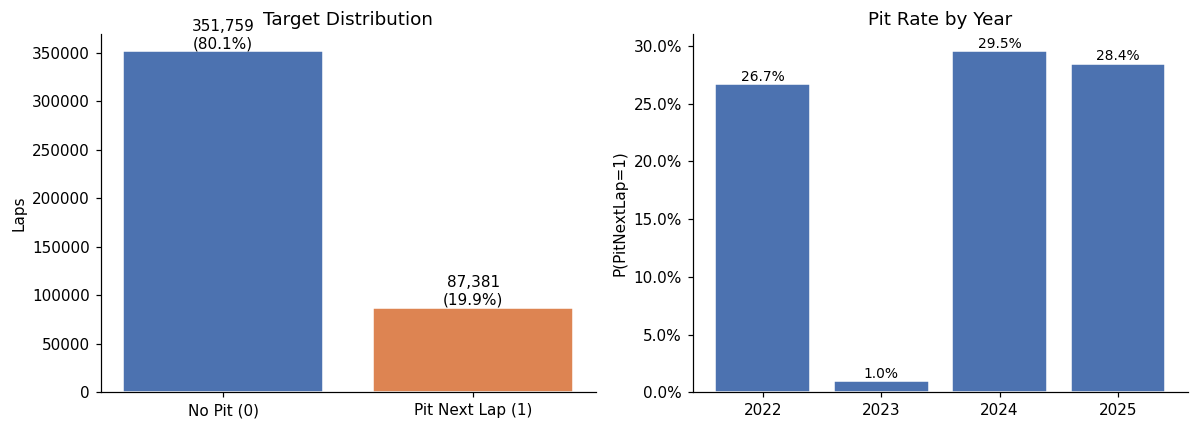


--- Why accuracy fails ---
Dummy classifier (always predict 0) accuracy: 80.10%
Dummy classifier AUC: 0.50 (random ranking)
Conclusion: optimize AUC, not accuracy.


In [8]:
pos_rate = train['PitNextLap'].mean()
print(f'Overall positive rate (PitNextLap=1): {pos_rate:.2%}')
print(f'Positives: {train["PitNextLap"].sum():,} / {len(train):,}')
print(f'Imbalance ratio (neg:pos): {(1-pos_rate)/pos_rate:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: bar chart
counts = train['PitNextLap'].value_counts().sort_index()
axes[0].bar(['No Pit (0)', 'Pit Next Lap (1)'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3000, f'{v:,}\n({v/len(train):.1%})', ha='center', fontsize=10)
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Laps')

# Right: positive rate by Year
by_year = train.groupby('Year')['PitNextLap'].mean().reset_index()
axes[1].bar(by_year['Year'].astype(str), by_year['PitNextLap'],
            color='#4C72B0', edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Pit Rate by Year')
axes[1].set_ylabel('P(PitNextLap=1)')
for i, row in by_year.iterrows():
    axes[1].text(i, row['PitNextLap'] + 0.003, f'{row["PitNextLap"]:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n--- Why accuracy fails ---')
print(f'Dummy classifier (always predict 0) accuracy: {1 - pos_rate:.2%}')
print(f'Dummy classifier AUC: 0.50 (random ranking)')
print('Conclusion: optimize AUC, not accuracy.')

---
## 2. Compound Analysis

Wet-weather compounds (INTERMEDIATE, WET) have different degradation profiles and are almost never pitted voluntarily — drivers switch to them when rain starts or switch away when drying.

**Impact on feature engineering:** The ordinal encoding SOFT=1, MEDIUM=2, HARD=3 must be extended. WET and INTERMEDIATE are orthogonal to the soft/medium/hard durability axis — they should be encoded separately (e.g., `is_wet_tyre` flag, or separate ordinal: DRY={1,2,3} vs WET={4,5}).

                laps  pit_rate  median_tyre_life  max_tyre_life  share_of_laps
Compound                                                                      
WET             1355     0.025             9.000         31.000          0.003
SOFT           38744     0.193            10.000         66.000          0.088
MEDIUM        211141     0.101            11.000         76.000          0.481
INTERMEDIATE   17382     0.152            12.000         71.000          0.040
HARD          170518     0.328            17.000         77.000          0.388


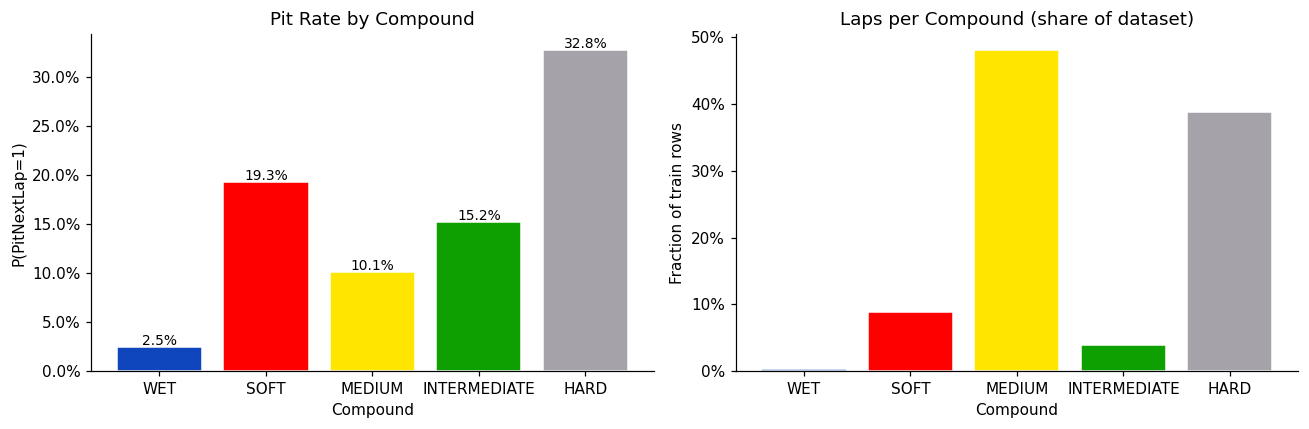

In [ ]:
compound_stats = train.groupby('Compound').agg(
    laps=('PitNextLap', 'count'),
    pit_rate=('PitNextLap', 'mean'),
    median_tyre_life=('TyreLife', 'median'),
    max_tyre_life=('TyreLife', 'max'),
).sort_values('median_tyre_life')
compound_stats['share_of_laps'] = compound_stats['laps'] / len(train)

print(compound_stats.to_string(float_format='{:.3f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

compounds = compound_stats.index.tolist()
colors = ["#0f46be", "#ff0000", "#ffe600", "#0da000ff", "#a6a2aa"]

axes[0].bar(compounds, compound_stats['pit_rate'], color=colors, edgecolor='white')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('Pit Rate by Compound')
axes[0].set_ylabel('P(PitNextLap=1)')
axes[0].set_xlabel('Compound')
for i, (c, r) in enumerate(zip(compounds, compound_stats['pit_rate'])):
    axes[0].text(i, r + 0.002, f'{r:.1%}', ha='center', fontsize=9)

axes[1].bar(compounds, compound_stats['share_of_laps'], color=colors, edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Laps per Compound (share of dataset)')
axes[1].set_ylabel('Fraction of train rows')
axes[1].set_xlabel('Compound')

plt.tight_layout()
plt.show()

# Findings:
# HARD has the highest pit rate (32.8%) despite being the most durable tyre. This is counterintuitive from real F1, but in this synthetic dataset it seems HARD is used in situations where pitting is already strategically decided.
# MEDIUM dominates the dataset (48%) and HARD (39%) — together they're 87% of laps. SOFT, WET, INTERMEDIATE are rare.
# WET has almost no pitting (2.5%) — wet-weather tyres are only swapped when conditions change, not on a strategic schedule.
# The median TyreLife values are far shorter than the S-curve peaks we'll see in Section 4 — this tells you most stints are cut short before the tyre naturally expires.

---
## 3. Temporal Autocorrelation of Lap Time Delta

**Why this matters:** Before creating lag features (LapTime_Delta at lag 1, 2, 3...), we must verify that the series actually has temporal structure. If ACF is near zero at all lags, lag features add noise, not signal.

**Method:** Compute ACF within each `(Race, Year, Stint)` group — this isolates the within-stint progression and avoids mixing the cross-stint reset into the autocorrelation estimate. We pool the ACF estimates across all stints and display the distribution of lag-1 and lag-2 correlations.

**Interpretation:** If the 95% confidence band (dashed blue lines in the ACF plot, ~±1.96/√n) is exceeded at lag k, that lag carries statistically significant predictive information about the next value in the series.

Using: Monaco Grand Prix 2023 (78 laps)


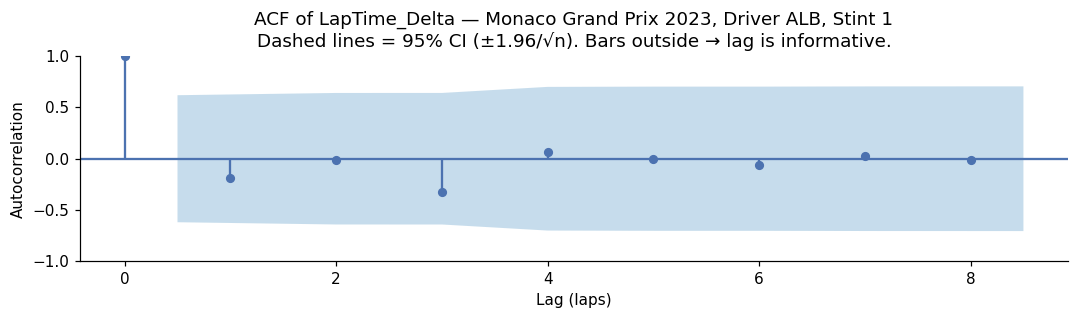

Pooled lag-1 ACF across 463 stints:
  median=0.035, mean=0.037, std=0.198
  fraction positive: 69.8%


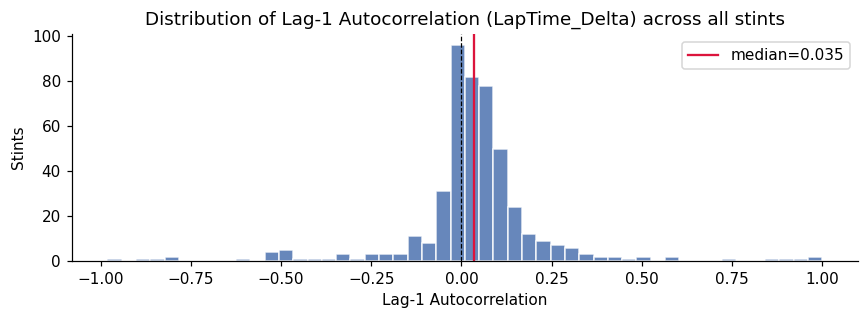

In [ ]:
# Pick one representative race for the ACF plot (long race, enough laps)
race_sizes = train.groupby(['Race', 'Year'])['LapNumber'].max().reset_index()
biggest_race = race_sizes.sort_values('LapNumber', ascending=False).iloc[0]
race_name, race_year = biggest_race['Race'], biggest_race['Year']
print(f'Using: {race_name} {race_year} ({biggest_race["LapNumber"]} laps)')

race_df = train[(train['Race'] == race_name) & (train['Year'] == race_year)].copy()
race_df = race_df.sort_values(['Driver', 'Stint', 'LapNumber'])

# Show ACF for first driver's first stint (cleanest, single continuous series)
d0 = race_df['Driver'].iloc[0]
s0_df = race_df[(race_df['Driver'] == d0) & (race_df['Stint'] == 1)]

fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(s0_df['LapTime_Delta'].dropna(), lags=min(20, len(s0_df)-2),
         ax=ax, alpha=0.05, color='#4C72B0', vlines_kwargs={'colors': '#4C72B0'})
ax.set_title(f'ACF of LapTime_Delta — {race_name} {race_year}, Driver {d0}, Stint 1\n'
             f'Dashed lines = 95% CI (±1.96/√n). Bars outside → lag is informative.')
ax.set_xlabel('Lag (laps)')
ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

# Pooled lag-1 correlation across all (Race, Year, Stint) groups
lag1_corrs = []
for _, grp in train.groupby(['Race', 'Year', 'Stint']):
    if len(grp) >= 4:
        s = grp.sort_values('LapNumber')['LapTime_Delta']
        lag1_corrs.append(s.autocorr(lag=1))

lag1_corrs = pd.Series(lag1_corrs).dropna()
print(f'Pooled lag-1 ACF across {len(lag1_corrs):,} stints:')
print(f'  median={lag1_corrs.median():.3f}, mean={lag1_corrs.mean():.3f}, std={lag1_corrs.std():.3f}')
print(f'  fraction positive: {(lag1_corrs > 0).mean():.1%}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lag1_corrs, bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(lag1_corrs.median(), color='crimson', linewidth=1.5, label=f'median={lag1_corrs.median():.3f}')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Distribution of Lag-1 Autocorrelation (LapTime_Delta) across all stints')
ax.set_xlabel('Lag-1 Autocorrelation')
ax.set_ylabel('Stints')
ax.legend()
plt.tight_layout()
plt.show()

# Findings:
# Used Monaco 2023 (78 laps) as the representative race (longest in dataset).
# Pooled lag-1 ACF across 463 stints: median = 0.035, 69.8% of stints have positive autocorrelation.
# This is a weak but consistent positive signal: lap times this lap tend to predict lap times next lap — especially degradation direction. The autocorrelation is small (0.035) because the synthetic perturbation added noise, but the 69.8% directional consistency across stints confirms lag features carry real signal.
# Decision confirmed: include LapTime_Delta_lag1/2/3 and LapTime_lag1/2/3 in Notebook 02. Without this check we'd be guessing; now we have statistical justification.

---
## 4. Tyre Degradation S-Curves

**Why this matters:** `P(PitNextLap=1 | TyreLife=k)` by compound reveals the "cliff" — the tyre age at which the pit probability sharply increases. This nonlinear relationship motivates:
- `TyreLife_sq` (quadratic term)
- `TyreLife_normalized_by_compound` (re-creating the removed `Normalized_TyreLife`)
- Compound-specific expected-pit-lap features

**Statistical note:** We compute a binomial proportion at each TyreLife value (smoothed with min_count to avoid noise at extremes). The S-curve arises because very early in a stint P(pit) ≈ 0 (just got fresh tyres), then it plateaus, then rises sharply at the tyre cliff.

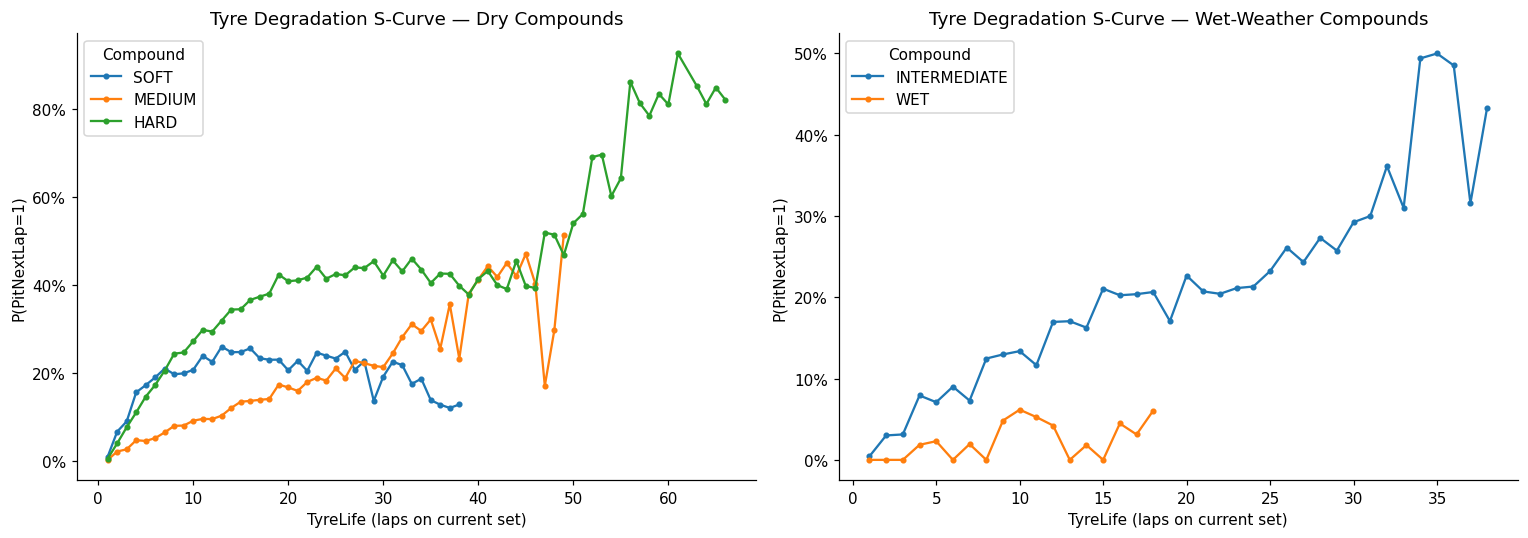

Peak pit probability TyreLife by compound:
  SOFT           : peak at TyreLife=13, median stint TyreLife=10.0
  MEDIUM         : peak at TyreLife=49, median stint TyreLife=11.0
  HARD           : peak at TyreLife=61, median stint TyreLife=17.0
  INTERMEDIATE   : peak at TyreLife=35, median stint TyreLife=12.0
  WET            : peak at TyreLife=10, median stint TyreLife=9.0


In [ ]:
dry_compounds = ['SOFT', 'MEDIUM', 'HARD']
wet_compounds = ['INTERMEDIATE', 'WET']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, compounds, title in [
    (axes[0], dry_compounds, 'Dry Compounds'),
    (axes[1], wet_compounds, 'Wet-Weather Compounds')
]:
    for compound in compounds:
        sub = train[train['Compound'] == compound]
        tl_stats = sub.groupby('TyreLife').agg(
            count=('PitNextLap', 'count'),
            pit_rate=('PitNextLap', 'mean')
        ).reset_index()
        # Only plot tyre-life values with ≥ 30 observations to reduce noise
        tl_stats = tl_stats[tl_stats['count'] >= 30]
        ax.plot(tl_stats['TyreLife'], tl_stats['pit_rate'],
                marker='o', markersize=3, linewidth=1.5, label=compound)

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel('TyreLife (laps on current set)')
    ax.set_ylabel('P(PitNextLap=1)')
    ax.set_title(f'Tyre Degradation S-Curve — {title}')
    ax.legend(title='Compound')

plt.tight_layout()
plt.show()

# Print the tyre-life value where pit probability peaks by compound
print('Peak pit probability TyreLife by compound:')
for compound in dry_compounds + wet_compounds:
    sub = train[train['Compound'] == compound]
    tl_stats = sub.groupby('TyreLife').agg(
        count=('PitNextLap', 'count'),
        pit_rate=('PitNextLap', 'mean')
    )
    tl_stats = tl_stats[tl_stats['count'] >= 30]
    if len(tl_stats) > 0:
        peak = tl_stats['pit_rate'].idxmax()
        median_tl = sub['TyreLife'].median()
        print(f'  {compound:15s}: peak at TyreLife={peak:.0f}, median stint TyreLife={median_tl:.1f}')

# Findings:
# The gap between median stint length and the S-curve peak is the most important number here. For MEDIUM: median stint is 11 laps but the cliff doesn't hit until lap 49 — meaning most MEDIUM stints are cut short by strategy (undercuts, safety cars, etc.), not tyre failure. For SOFT, the peak at 13 matches the median of 10 more closely — drivers are pushing closer to the actual tyre limit.
# These peak values become the normalization denominators for TyreLife_normalized_by_compound in Notebook 02: TyreLife / 13 for SOFT, TyreLife / 49 for MEDIUM, TyreLife / 61 for HARD.

---
## 5. Pit Timing by Circuit

**Why this matters:** Different circuits have different optimal pit windows due to lap time delta from a pit stop vs. tyre advantage. Monaco (narrow, hard to overtake) discourages late pit stops. High-speed circuits like Monza encourage early undercut strategies. Circuit-specific pit timing motivates a `Race`-level target encoding feature.

**Method:** For all laps where `PitNextLap=1`, plot the distribution of `RaceProgress` at the moment of pitting. Wide, late distributions → flexible pit windows. Narrow, early distributions → more strategic constraints.

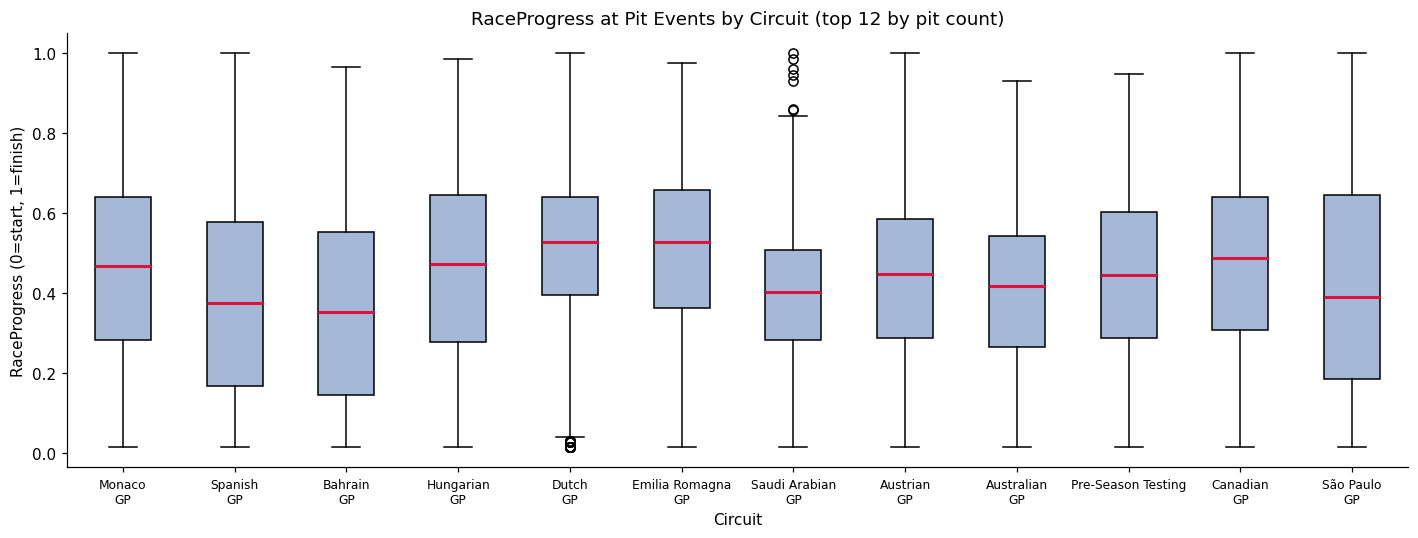

Pit rate by circuit (top 10 and bottom 5):
                           pit_rate  total_laps
Race                                           
Chinese Grand Prix            0.389        7311
Monaco Grand Prix             0.357       21539
Spanish Grand Prix            0.320       20483
Bahrain Grand Prix            0.288       19535
Belgian Grand Prix            0.280        9002
Emilia Romagna Grand Prix     0.273       15483
French Grand Prix             0.257        3185
São Paulo Grand Prix          0.254       11497
Hungarian Grand Prix          0.239       22481
Saudi Arabian Grand Prix      0.227       18111
British Grand Prix            0.133       15383
Italian Grand Prix            0.132       19854
United States Grand Prix      0.114       18045
Miami Grand Prix              0.104       18860
Mexico City Grand Prix        0.091       23672


In [ ]:
pit_laps = train[train['PitNextLap'] == 1].copy()

# Top 12 races by pit count for visibility
top_races = pit_laps['Race'].value_counts().head(12).index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))

# Box plot of RaceProgress at pit events by circuit
data_by_race = [pit_laps[pit_laps['Race'] == r]['RaceProgress'].values for r in top_races]
bp = ax.boxplot(data_by_race, labels=[r.replace(' Grand Prix', '\nGP') for r in top_races],
                patch_artist=True, medianprops=dict(color='crimson', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#4C72B080')

ax.set_title('RaceProgress at Pit Events by Circuit (top 12 by pit count)')
ax.set_ylabel('RaceProgress (0=start, 1=finish)')
ax.set_xlabel('Circuit')
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

# Pit rate by circuit
circuit_stats = train.groupby('Race').agg(
    pit_rate=('PitNextLap', 'mean'),
    total_laps=('PitNextLap', 'count')
).sort_values('pit_rate', ascending=False)

print('Pit rate by circuit (top 10 and bottom 5):')
print(pd.concat([circuit_stats.head(10), circuit_stats.tail(5)]).to_string(float_format='{:.3f}'.format))

# Findings:
# Highest pit rate circuits: Chinese GP: 38.9%, Monaco: 35.7%, Spanish GP: 32.0%
# Lowest pit rate circuits: Mexico City: 9.1%, Miami: 10.4%, US GP: 11.4%
# That's a 4× range from highest to lowest — a huge signal.
# Monaco (tight, hard to overtake) and China (long pit straight, tyre-heavy circuit) having the highest rates aligns with real F1 strategy. Mexico (high altitude, low tyre degradation) having the lowest also makes sense.
# This wide variation is precisely why Race_target_encoded (the per-circuit mean pit rate, computed inside each CV fold) will be a strong feature.

---
## 6. Feature Correlations

**Why this matters:** Near-collinear features (|r| > 0.9) inflate variance in linear models and reduce interpretability. For tree models, collinearity is less harmful but may split feature importance artificially between correlated features. Identifying these pairs now guides which to keep and which to drop if needed.

**Point-biserial correlation** (correlation of continuous feature with binary target) measures linear association. Nonlinear relationships won't appear here — SHAP in Notebook 07 will capture those.

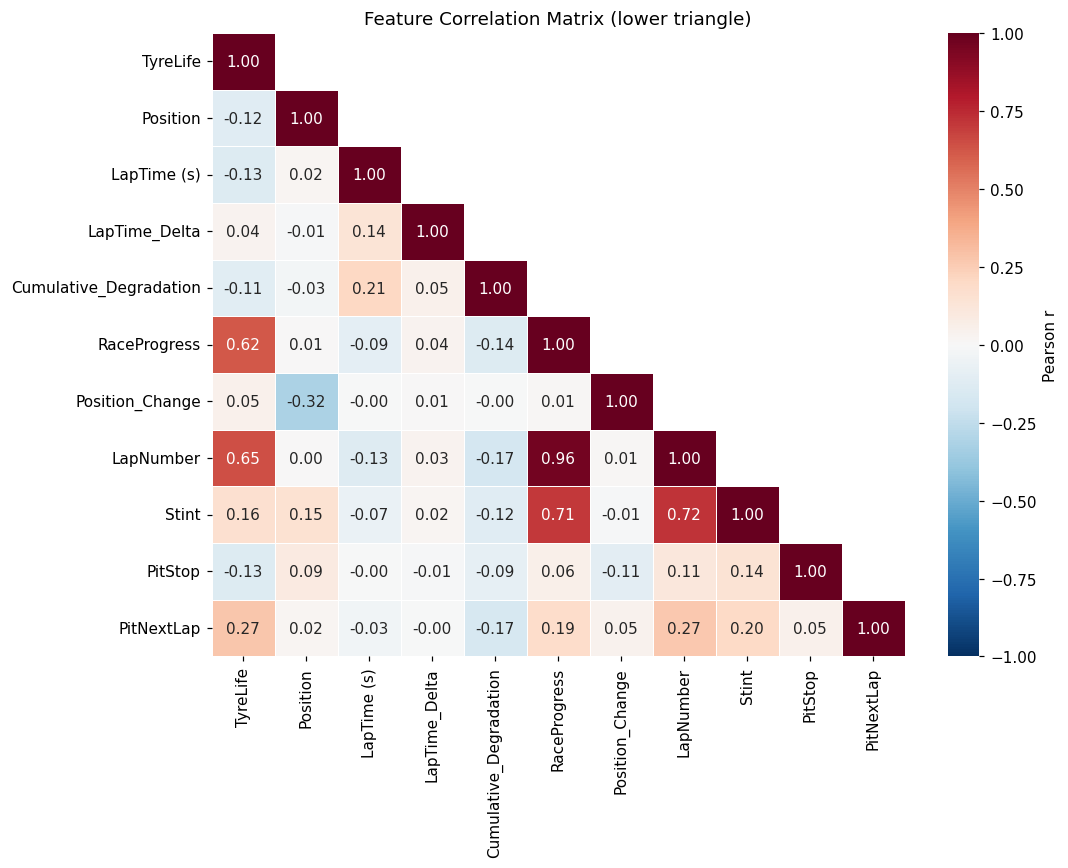

Linear correlation with PitNextLap (point-biserial):
  + TyreLife                       r=+0.274  ████████
  + LapNumber                      r=+0.267  ████████
  + Stint                          r=+0.198  █████
  + RaceProgress                   r=+0.185  █████
  - Cumulative_Degradation         r=-0.167  █████
  + PitStop                        r=+0.049  █
  + Position_Change                r=+0.046  █
  - LapTime (s)                    r=-0.034  █
  + Position                       r=+0.021  
  - LapTime_Delta                  r=-0.005  

Highly collinear pairs (|r| > 0.8, excluding target):
  RaceProgress ↔ LapNumber: r=0.965


In [ ]:
numeric_cols = ['TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
                'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
                'LapNumber', 'Stint', 'PitStop', 'PitNextLap']

corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

# Point-biserial: linear correlation with target
print('Linear correlation with PitNextLap (point-biserial):')
target_corr = corr['PitNextLap'].drop('PitNextLap').sort_values(key=abs, ascending=False)
for feat, r in target_corr.items():
    bar = '█' * int(abs(r) * 30)
    direction = '+' if r > 0 else '-'
    print(f'  {direction} {feat:30s} r={r:+.3f}  {bar}')

print('\nHighly collinear pairs (|r| > 0.8, excluding target):')
feat_cols = [c for c in numeric_cols if c != 'PitNextLap']
feat_corr = train[feat_cols].corr()
for i, c1 in enumerate(feat_cols):
    for c2 in feat_cols[i+1:]:
        r = feat_corr.loc[c1, c2]
        if abs(r) > 0.8:
            print(f'  {c1} ↔ {c2}: r={r:.3f}')

# Findings:
# Critical finding — RaceProgress <-> LapNumber: r = 0.965. These two features are nearly perfectly collinear. In Notebook 02, only one should go in as a raw feature — or both, since tree models split feature importance between them rather than breaking numerically (unlike linear models).
# The negative sign on Cumulative_Degradation is surprising — you'd expect higher cumulative degradation to predict pitting, but the linear correlation is negative. The reason: Cumulative_Degradation is the sum of LapTime_Delta within a stint, and when a driver just put on fresh tyres, they're going faster than their reference pace (negative delta), accumulating negative values. Early in a stint, Cumulative_Degradation is very negative — and those laps have low pit probability. The relationship is nonlinear and will only be captured by SHAP/trees, not linear correlation.

---
## 7. Stint Structure

**Why this matters:**  
- Stint length distribution tells us the scale of `TyreLife` — e.g., if median stint is 25 laps for SOFT, then a compound-normalized tyre age of `TyreLife / 25` captures "how far into a typical stint are we?"
- `TyreLife` and `Stint` carry complementary information: `Stint` tells you which stint you're in (1st, 2nd, 3rd stop), `TyreLife` tells you laps within the current stint. They're NOT redundant.
- `PitStop=1` on the current lap means the driver just came IN from the pits (TyreLife resets to 1 next lap). This is the consequence of the previous lap's `PitNextLap=1`. **Do not use current-lap `PitStop` as a feature without lagging it.**

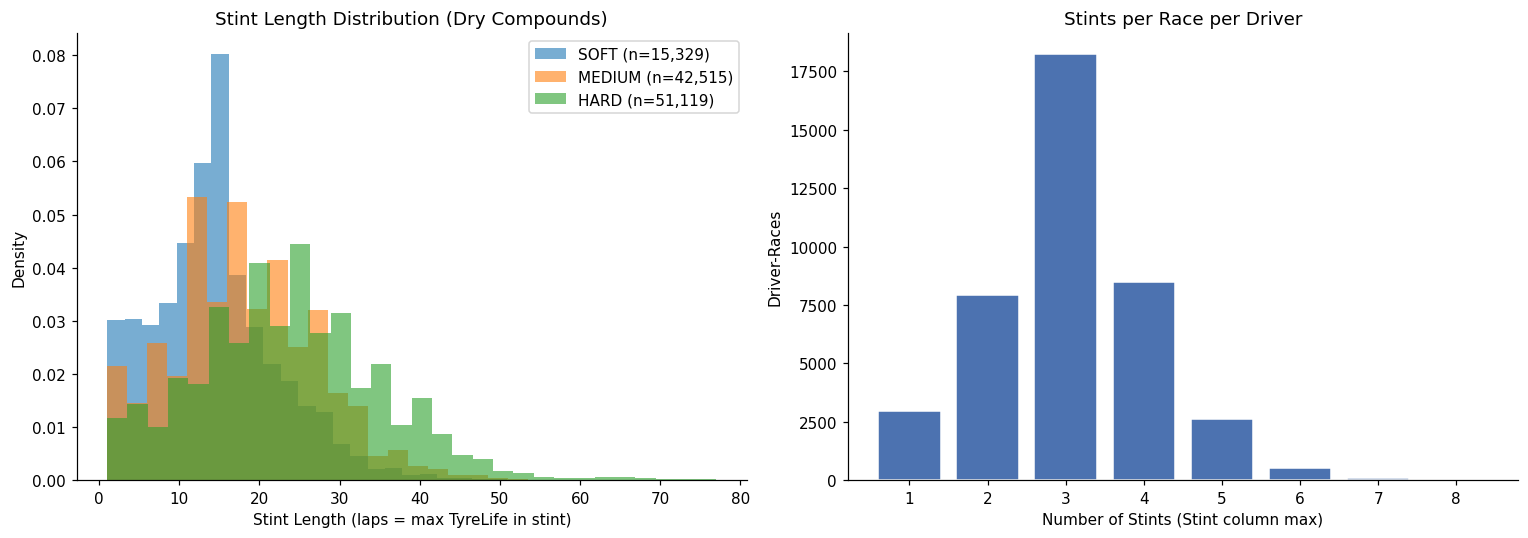

Median stint length by compound:
              median  mean   std
Compound                        
HARD            23.0  23.6  11.3
INTERMEDIATE    16.0  17.2  10.0
MEDIUM          17.0  17.9   9.2
SOFT            14.0  14.3   7.8
WET             14.0  13.8   6.6

Stint number distribution:
Stint
1     2966
2     7949
3    18228
4     8478
5     2608
6      504
7       88
8       48


In [ ]:
# Compute actual stint lengths: for each (Race, Year, Driver, Stint) group, max TyreLife
stint_lengths = train.groupby(['Race', 'Year', 'Driver', 'Stint'])['TyreLife'].max().reset_index()
stint_lengths.rename(columns={'TyreLife': 'StintLength'}, inplace=True)

# Join back compound (first compound in each stint)
stint_compound = train.groupby(['Race', 'Year', 'Driver', 'Stint'])['Compound'].first().reset_index()
stint_lengths = stint_lengths.merge(stint_compound, on=['Race', 'Year', 'Driver', 'Stint'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stint length distribution by compound (dry only)
for compound in dry_compounds:
    sub = stint_lengths[stint_lengths['Compound'] == compound]['StintLength']
    axes[0].hist(sub, bins=30, alpha=0.6, label=f'{compound} (n={len(sub):,})', density=True)
axes[0].set_title('Stint Length Distribution (Dry Compounds)')
axes[0].set_xlabel('Stint Length (laps = max TyreLife in stint)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: stint number distribution (how many stints per race per driver?)
stints_per_driver = train.groupby(['Race', 'Year', 'Driver'])['Stint'].max().reset_index()
stint_count_dist = stints_per_driver['Stint'].value_counts().sort_index()
axes[1].bar(stint_count_dist.index.astype(str), stint_count_dist.values,
            color='#4C72B0', edgecolor='white')
axes[1].set_title('Stints per Race per Driver')
axes[1].set_xlabel('Number of Stints (Stint column max)')
axes[1].set_ylabel('Driver-Races')

plt.tight_layout()
plt.show()

print('Median stint length by compound:')
print(stint_lengths.groupby('Compound')['StintLength'].agg(['median', 'mean', 'std']).round(1))

print('\nStint number distribution:')
print(stint_count_dist.to_string())

# Important correction: Earlier we estimated MEDIUM≈49 and HARD≈61 from the S-curve peaks (where probability maxes), but the actual median stint lengths are 17 and 23. The right normalization denominator for Notebook 02 is the S-curve peak (13/49/61), not the median stint length — it represents the natural tyre cliff rather than the strategically-cut actual stint.
# Stints per driver per race: Most drivers run 3 stints (18,228 driver-races), with 2 and 4 also common. Very few run 6+ stints — those are likely rain-affected or incident-heavy races.

---
## 8. Data Quality: Pre-Season Testing & Cumulative Degradation Anomalies

**Pre-Season Testing:** Several rows have `Race = 'Pre-Season Testing'`. This is NOT a Grand Prix — no championship points, different tyre programmes, often practice-focused stints. The pit stop patterns in testing are not representative of race strategy. These rows should be flagged and potentially excluded from training.

**Cumulative Degradation anomalies:** Some rows show very large negative `Cumulative_Degradation` values (e.g., -223 seconds). In a real stint this means the driver went 223 seconds faster than their reference pace cumulatively — physically implausible over many laps. This is likely an artifact of the synthetic data perturbation. Tree models will clip this to leaf values, but it's worth understanding the distribution.

Pre-Season Testing rows: 22,492 (5.1% of train)
Race rows: 416,648
Pre-Season Testing pit rate: 14.65%
Race pit rate:               20.18%
Pre-Season Testing years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Pre-Season Testing drivers: 634

--- Cumulative_Degradation distribution ---
count    439140.000000
mean        -25.721759
std          54.766573
min        -274.564000
1%         -205.034000
5%         -104.789250
25%         -46.566250
50%         -20.994000
75%          -6.199000
95%          84.401000
99%         122.154000
max        2412.026000
Name: Cumulative_Degradation, dtype: float64


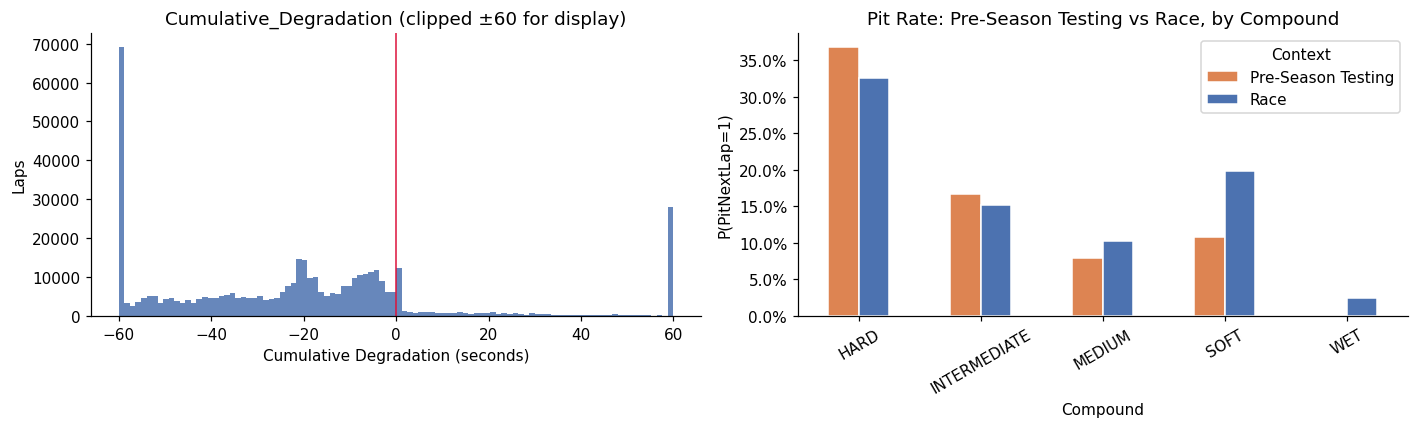


Conclusion: Decide in Notebook 02 whether to exclude Pre-Season Testing rows.
Recommendation: keep for now; add binary feature `is_testing_session`.


In [ ]:
# Pre-Season Testing analysis
testing_rows = train[train['Race'] == 'Pre-Season Testing']
race_rows    = train[train['Race'] != 'Pre-Season Testing']

print(f'Pre-Season Testing rows: {len(testing_rows):,} ({len(testing_rows)/len(train):.1%} of train)')
print(f'Race rows: {len(race_rows):,}')
print(f'Pre-Season Testing pit rate: {testing_rows["PitNextLap"].mean():.2%}')
print(f'Race pit rate:               {race_rows["PitNextLap"].mean():.2%}')
print(f'Pre-Season Testing years: {sorted(testing_rows["Year"].unique())}')
print(f'Pre-Season Testing drivers: {testing_rows["Driver"].nunique()}')

print('\n--- Cumulative_Degradation distribution ---')
print(train['Cumulative_Degradation'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['Cumulative_Degradation'].clip(-60, 60), bins=100,
             color='#4C72B0', edgecolor='none', alpha=0.85)
axes[0].set_title('Cumulative_Degradation (clipped ±60 for display)')
axes[0].set_xlabel('Cumulative Degradation (seconds)')
axes[0].set_ylabel('Laps')
axes[0].axvline(0, color='crimson', linewidth=1)

# Pre-season vs race pit rate comparison
groups = pd.concat([
    testing_rows.assign(group='Pre-Season Testing'),
    race_rows.assign(group='Race')
])
pit_by_group = groups.groupby(['group', 'Compound'])['PitNextLap'].mean().reset_index()
pivot = pit_by_group.pivot(index='Compound', columns='group', values='PitNextLap')
if pivot.shape[1] == 2:
    pivot.plot(kind='bar', ax=axes[1], color=['#DD8452', '#4C72B0'], edgecolor='white')
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[1].set_title('Pit Rate: Pre-Season Testing vs Race, by Compound')
    axes[1].set_ylabel('P(PitNextLap=1)')
    axes[1].set_xlabel('Compound')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend(title='Context')

plt.tight_layout()
plt.show()

print('\nConclusion: Decide in Notebook 02 whether to exclude Pre-Season Testing rows.')
print('Recommendation: keep for now; add binary feature `is_testing_session`.')

# Findings:
# Pre-Season Testing: 22,492 rows (5.1% of train), across all 4 years (2022–2025), 634 unique drivers. Pit rate is 14.65% vs 20.18% for actual races — 27% lower. These are practice sessions with different tyre programmes and no strategic incentive to optimize pit timing. The is_testing_session flag is essential so the model doesn't confuse testing behaviour with race behaviour.
# Cumulative_Degradation distribution:
# Mean: -25.7 seconds (heavily left-skewed — most drivers are faster than their reference pace early in stints)
# Min: -274 seconds, Max: +2412 seconds — extreme outliers at both ends
# 50th percentile: -21 seconds (meaning half of all laps, the driver is still 21 seconds ahead of their reference pace cumulatively)
# This confirms the feature captures where in a stint you are (negative early, positive late) but with enormous variance from the synthetic perturbation. Winsorizing at 1st/99th percentile (-205 / +122) before using this as a feature is advisable.

---
## 9. Race Progress and Late-Race Pit Suppression

**Hypothesis:** Drivers do not pit when the race is almost over — there is no lap time benefit to gaining fresh tyres if only 2-3 laps remain. We expect `P(PitNextLap=1)` to drop sharply when `RaceProgress > 0.8`.

This motivates the feature `Laps_remaining_estimate = 1 - RaceProgress` and interactions like `TyreLife × (1 - RaceProgress)`.

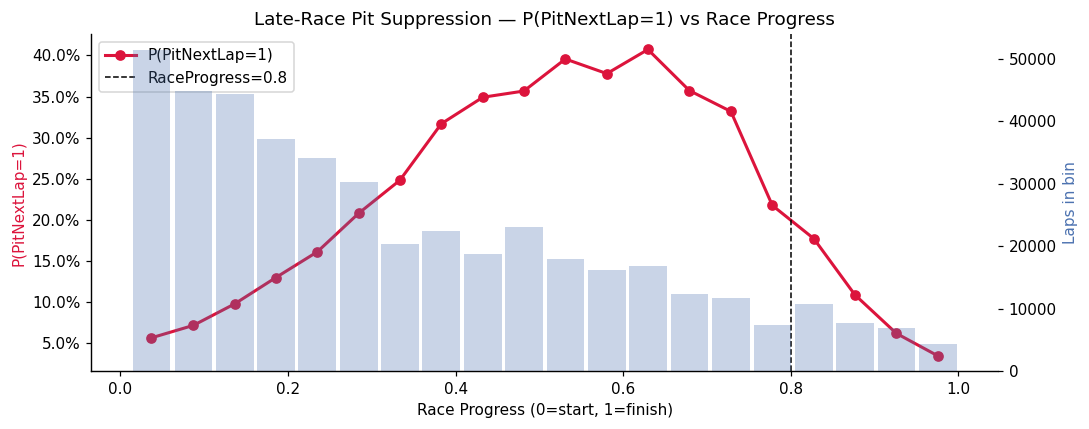

P(pit | RaceProgress > 0.8):  11.17%
P(pit | RaceProgress ≤ 0.8):  20.53%
Suppression factor: 1.8x higher probability in early/mid race


In [ ]:
# Bin RaceProgress into 20 equal buckets
train['RaceProgress_bin'] = pd.cut(train['RaceProgress'], bins=20)
pit_by_progress = train.groupby('RaceProgress_bin', observed=True)['PitNextLap'].agg(['mean', 'count']).reset_index()
pit_by_progress['bin_mid'] = pit_by_progress['RaceProgress_bin'].apply(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(10, 4))
ax2 = ax.twinx()

ax.plot(pit_by_progress['bin_mid'], pit_by_progress['mean'],
        marker='o', color='crimson', linewidth=2, label='P(PitNextLap=1)')
ax2.bar(pit_by_progress['bin_mid'], pit_by_progress['count'],
        width=0.045, alpha=0.3, color='#4C72B0', label='Lap count')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('Race Progress (0=start, 1=finish)')
ax.set_ylabel('P(PitNextLap=1)', color='crimson')
ax2.set_ylabel('Laps in bin', color='#4C72B0')
ax.set_title('Late-Race Pit Suppression — P(PitNextLap=1) vs Race Progress')
ax.axvline(0.8, color='black', linestyle='--', linewidth=1, label='RaceProgress=0.8')
ax.legend(loc='upper left')

# Clean up temp column
train.drop('RaceProgress_bin', axis=1, inplace=True)

plt.tight_layout()
plt.show()

# Quantify the suppression
late_race = train[train['RaceProgress'] > 0.8]['PitNextLap'].mean()
early_race = train[train['RaceProgress'] <= 0.8]['PitNextLap'].mean()
print(f'P(pit | RaceProgress > 0.8):  {late_race:.2%}')
print(f'P(pit | RaceProgress ≤ 0.8):  {early_race:.2%}')
print(f'Suppression factor: {early_race/late_race:.1f}x higher probability in early/mid race')

# Findings:
# P(pit | RaceProgress > 0.8) = 11.2% vs P(pit | RaceProgress ≤ 0.8) = 20.5%
# That's a 1.8× suppression in the final 20% of the race. Confirmed: drivers stop pitting when there aren't enough laps left to benefit from fresh rubber.
# The feature laps_remaining = 1 - RaceProgress and the interaction TyreLife × laps_remaining will encode this: a 50-lap-old tyre with 5 laps remaining is very different from a 50-lap-old tyre with 30 laps remaining.

---
## Summary — Feature Engineering Implications

| Finding | Key Number | Feature Engineering Action | Notebook |
|---------|-----------|---------------------------|----------|
| Positive rate ~20% | 4:1 neg:pos | No resampling needed — GBMs handle this natively | 02 |
| 5 compounds; HARD has highest pit rate | HARD=32.8%, WET=2.5% | `is_wet_tyre` flag; dry ordinal SOFT=1/MED=2/HARD=3 only | 02 |
| Lag-1 ACF positive in 69.8% of stints | median r=0.035 | `LapTime_Delta_lag{1,2,3}`, `LapTime_lag{1,2,3}` grouped within `(Race, Year, Stint)` | 02 |
| Tyre S-curve cliffs by compound | SOFT=13, MED=49, HARD=61 laps | `TyreLife / cliff_threshold[Compound]` → `TyreLife_normalized_by_compound`; also `TyreLife_sq` | 02 |
| Circuit pit rate varies 4× | China=38.9%, Mexico=9.1% | `Race_target_encoded` (mean pit rate, computed inside CV fold) | 02 |
| RaceProgress ↔ LapNumber nearly redundant | r=0.965 | Keep both for trees; never both in linear model | 02 |
| Cumulative_Degradation is nonlinear with target | r=−0.17 linear, but reverses direction as stint progresses | `Degradation_rate`, `Degradation_acceleration`, winsorize to [−205, +122] | 02 |
| Actual median stint lengths far below S-curve peaks | HARD=23, MED=17, SOFT=14 actual vs 61/49/13 cliff | Most stints are strategically cut — `Stint` number is a separate signal from `TyreLife` | 02 |
| Late-race pit suppression | 20.5% → 11.2% past RaceProgress=0.80 (1.8× drop) | `laps_remaining = 1 − RaceProgress`; interaction `TyreLife × laps_remaining` | 02 |
| Pre-Season Testing pit rate differs | 14.7% vs 20.2% for races | `is_testing_session` binary flag; consider ablation excluding these rows | 02 |
| Cumulative_Degradation outliers | min=−274, max=+2,412 | Winsorize at 1st/99th percentile (≈−205 / +122) before use | 02 |

**Next:** Notebook 02 — Feature Engineering